In [94]:
# import system libraries
import logging
import sys, copy
# import scientific libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal
from scipy.interpolate import InterpolatedUnivariateSpline as spline
import h5py
import pandas as pd
# import data analysis libraries
from ldc.waveform.lisabeta import FastBHB
import lisabeta.lisa.lisa as lisa
from lisabeta.lisa.lisa import EvaluateTDIFreqseries
import lisabeta.tools.pyspline as pyspline
import lisabeta.lisa.lisatools as lisatools
import lisabeta.tools.pytools as pytools
from ldc.common import tools
from ldc.lisa.noise import AnalyticNoise, get_noise_model
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import lisaconstants
# import sampler libraries
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer
from ldc.waveform.waveform import HpHc

mpl.rcParams.update(mpl.rcParamsDefault)

# Set up injection and find noiseless Afull and Efull. Set up Npsd, timing, and frequencies

In [95]:
#imports all dependencies and homebrewed functions
import LISA_TTL_Functions as foc

In [96]:
#set up the injection

pMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932,
 'Mass2': 612485.5060299999,
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559, #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

snr = 22295 for distance 1347.983559
snr = 223 for distance 134700

In [97]:
snr_unrounded = foc.snr_check(pMBHB_ldc)
snr = int(snr_unrounded)
print(snr)

223.11312052151075
223


In [98]:
A_full, E_full, Npsd, src, src0, freq, keys = foc.Fulls(pMBHB_ldc)

In [99]:
#establish t_min, max, separation and number of samples
t_min = 0
t_max = pMBHB_ldc["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

In [100]:
#set up the injection in lisabeta terms
FBH = FastBHB("MBHB", T=t_max, delta_t=dt, approx="IMRPhenomD")

pMBHB = FBH.rename_as_lisabeta(pMBHB_ldc)

print(pMBHB.keys())

dict_keys(['beta', 'lambda', 'chi1', 'chi2', 'm1', 'm2', 'Deltat', 'phi', 'dist', 'psi', 'inc'])


In [101]:
#background settings
waveform_params_smbh = {
    "minf": 1e-5,
    "maxf": 1,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "tmax": 1.0,
    "TDI": "TDIAET",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": False
}

In [102]:
#generate signal
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, **waveform_params_smbh)
tdi = tdisignal['tdi']
mbh_lb = tdi[(2,2)]
#generate frequency grid
freq = mbh_lb['freq']
freq = freq[freq>0]
#generate data
A_full = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1'])*np.exp(1j* mbh_lb['phase']))
E_full = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2'])*np.exp(1j* mbh_lb['phase']))
#generate noise PSD
Nmodel = AnalyticNoise(freq, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)

In [103]:
Afull = A_full
Efull = E_full

# Set up the MCMC: array for trials, likelihood, priors, initial condition, temps, walkers, samples, etc

In [104]:
#now we set things up for mcmc
#solving for chirpmass and ratio
m1 = pMBHB['m1']
m2 = pMBHB['m2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

src0 = pMBHB.copy()
src0.pop("m1"); src0.pop("m2")
src0["Mchirp"] = Mc
src0["q"] = q
src0['psi'] += np.pi
src0['phi'] -= np.pi

keys = src0.keys()

#create the array to be altered in likelihood
src = copy.deepcopy(src0)

In [105]:
##change the likelihood function
def likelihood(params):
    src={k: v for k,v in zip(keys,params)}

    tdisignal = lisa.GenerateLISATDISignal_SMBH(src,
                                                gridfreq=freq,
                                                **waveform_params_smbh)
    mbh_lb = tdisignal['tdi'][(2,2)]

    A_trial = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1'])*np.exp(1j* mbh_lb['phase']))
    E_trial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2'])*np.exp(1j* mbh_lb['phase']))

    SN_m = 4.0*df*np.sum(np.real(Afull*np.conjugate(A_trial))/Npsd) + 4.0*df*np.sum(np.real(Efull*np.conjugate(E_trial))/Npsd)

    XX = 4*df*np.sum(np.abs(A_trial)**2/Npsd) + 4*df*np.sum(np.abs(E_trial)**2/Npsd)

    loglik = SN_m - 0.5*XX
    return loglik

In [106]:
day_sec = 86400

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-np.pi/2, np.pi/2), #lambda
    1: uniform_dist(-np.pi, np.pi), #beta
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(100*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(0., np.pi), #inc
    9: uniform_dist(1e4, 1e7), #mchirp
    10: uniform_dist(1, 30), #q
})}

ndims = {"mbh": 11}

In [107]:
ntemps = 5
nwalkers = 22
nsamples = 50000
ndims = {"mbh": 11}

In [108]:
theta0 = np.array([[np.hstack(
          (np.random.randn(ndims["mbh"]) * 1e-8) + np.array(list(src0.values())))
          for i in range(nwalkers)]
          for _ in range(ntemps)])
#keys = src0.keys()

start_state = State({"mbh": theta0})

In [109]:
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

# Run the MCMC

In [110]:
sampler.run_mcmc(start_state, nsamples, progress=True)

100%|██████████| 50000/50000 [20:07<00:00, 41.42it/s]


# Plot corner and walkers

In [111]:
#define truths
keys = src0.keys()
labels = list(keys)

inj=np.array(list(src0.values()))

truths = inj.flatten()
labels_final = labels

In [112]:
burn = 20000

Parameter phi in chain noiseless is not constrained
Parameter psi in chain noiseless is not constrained
Parameter inc in chain noiseless is not constrained


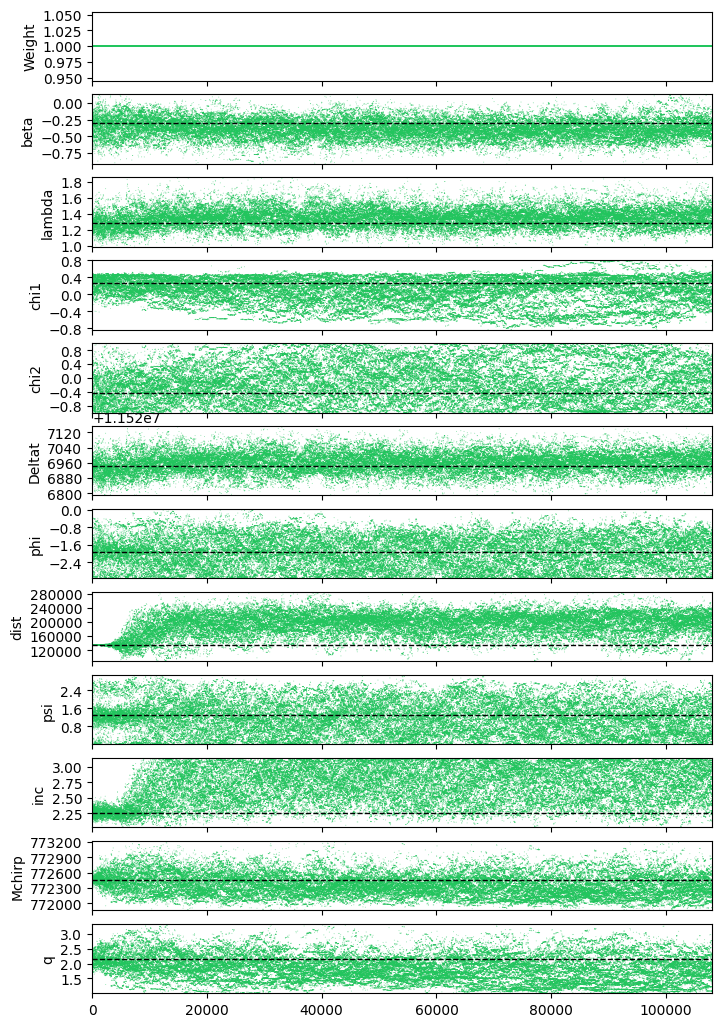

In [113]:
c = ChainConsumer()

samples_2ch = sampler.get_chain()["mbh"][:, 0].reshape(-1, 11)

dfs_2chnls = pd.DataFrame(samples_2ch[burn:, :], columns = keys)

c.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="green"))
c.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

c.plotter.plot()
c.plotter.plot_walks()

In [114]:
csv_filename_0mm = "0mm_"+ str(snr) + "_snr_chains.csv"
dfs_2chnls.to_csv(csv_filename_0mm, index=False)
print(f"Chain data saved to {csv_filename_0mm}")

Chain data saved to 0mm_223_snr_chains.csv


# Add 1mm noise to the waveform

In [115]:
#a constant
fstar = 0.0190854 #c/L/(2*np.pi)

In [116]:
#generate noise psd for 1mm
psd_sqrt = 6e-11*(np.sin(2*freq/fstar)**2 + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10

#Add noise function
def randc(r):
    return r/np.sqrt(2)*(np.random.randn(*r.shape) + 1j*np.random.randn(*r.shape))

#create noise fft
noise_fft = randc(psd_sqrt)

In [117]:
#add noisy noise to signal
Afull = A_full+ noise_fft/np.sqrt(df*4)
Efull = E_full+ noise_fft/np.sqrt(df*4)

# Rerun the same MCMC with 1mm

In [118]:
sampler2 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [119]:
sampler2.run_mcmc(start_state, nsamples, progress=True)

100%|██████████| 50000/50000 [19:35<00:00, 42.52it/s]


# Plot walkers and corners 1mm

Parameter phi in chain 1mm is not constrained
Parameter psi in chain 1mm is not constrained
Parameter inc in chain 1mm is not constrained


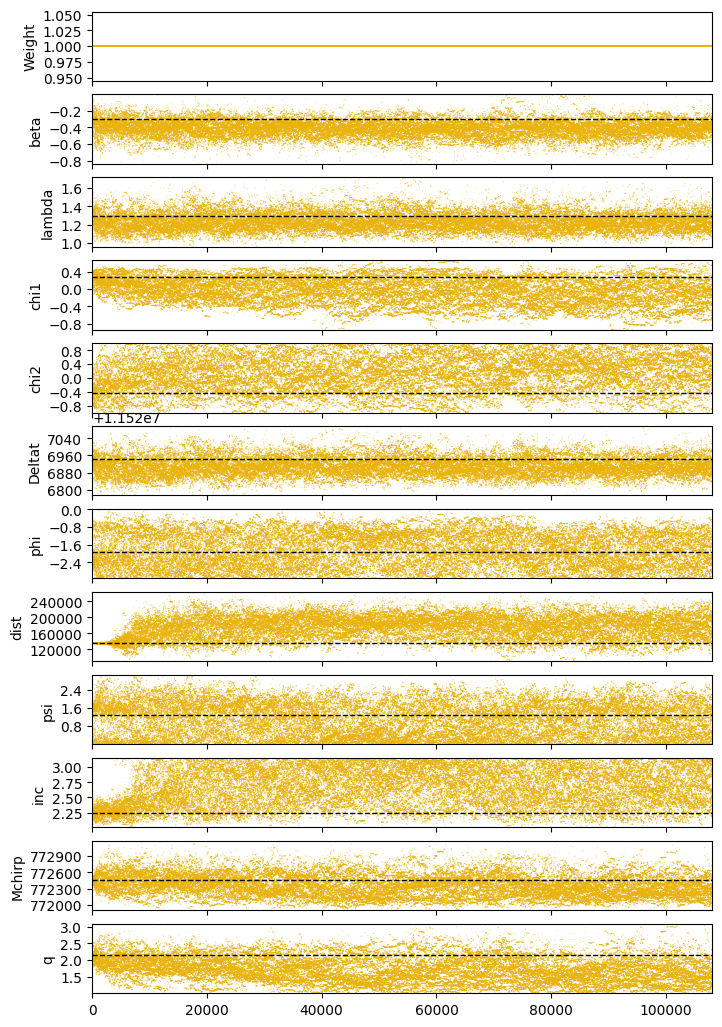

In [120]:
a = ChainConsumer()

one_samples = sampler2.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 30000
one_samp= pd.DataFrame(one_samples[burn:, :], columns = keys)

a.add_chain(Chain(samples=one_samp, name="1mm", color="yellow"))
a.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

a.plotter.plot()
a.plotter.plot_walks()

In [121]:
csv_filename_1mm = "1mm_"+ str(snr) + "_snr_chains.csv"
one_samp.to_csv(csv_filename_1mm, index=False)
print(f"Chain data saved to {csv_filename_1mm}")

Chain data saved to 1mm_223_snr_chains.csv


# Add 2mm noise to the waveform

In [122]:
#generate noise psd for 1mm
psd_sqrt = 2e-10*(np.sin(2*freq/fstar)**2 + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10


noise_fft = randc(psd_sqrt)

#add noisy noise to signal
Afull = A_full+ noise_fft/np.sqrt(df*4)
Efull = E_full+ noise_fft/np.sqrt(df*4)

# Rerun the same MCMC with 2mm

In [123]:
sampler3 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [124]:
sampler3.run_mcmc(start_state, nsamples, progress=True)

100%|██████████| 50000/50000 [20:29<00:00, 40.68it/s]


# Corners and Chains for 2mm

Parameter phi in chain 2mm is not constrained
Parameter dist in chain 2mm is not constrained
Parameter inc in chain 2mm is not constrained


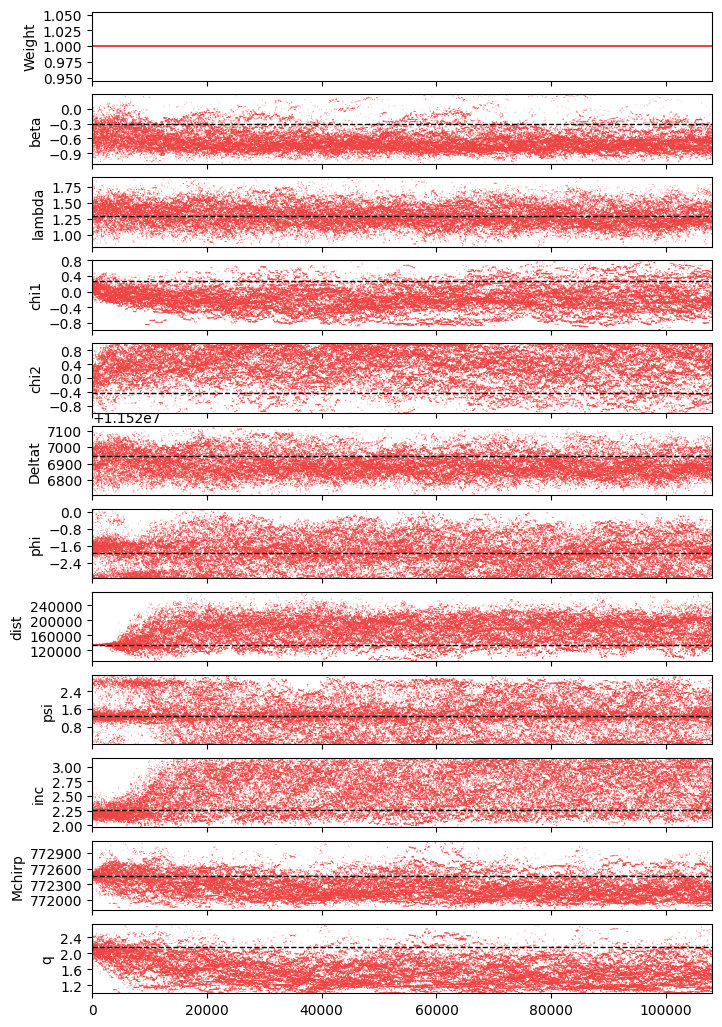

In [125]:
b = ChainConsumer()

two_samples = sampler3.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 800000
two_samp= pd.DataFrame(two_samples[burn:, :], columns = keys)

b.add_chain(Chain(samples=two_samp, name="2mm", color="red"))
b.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

b.plotter.plot()
b.plotter.plot_walks()

In [126]:
csv_filename_2mm = "2mm_"+ str(snr) + "_snr_chains.csv"
two_samp.to_csv(csv_filename_2mm, index=False)
print(f"Chain data saved to {csv_filename_2mm}")

Chain data saved to 2mm_223_snr_chains.csv


# Let'd do a small checkin with those three chains

Parameter phi in chain noiseless is not constrained
Parameter phi in chain 1mm is not constrained
Parameter phi in chain 2mm is not constrained
Parameter dist in chain 2mm is not constrained
Parameter psi in chain noiseless is not constrained
Parameter psi in chain 1mm is not constrained
Parameter inc in chain noiseless is not constrained
Parameter inc in chain 1mm is not constrained
Parameter inc in chain 2mm is not constrained


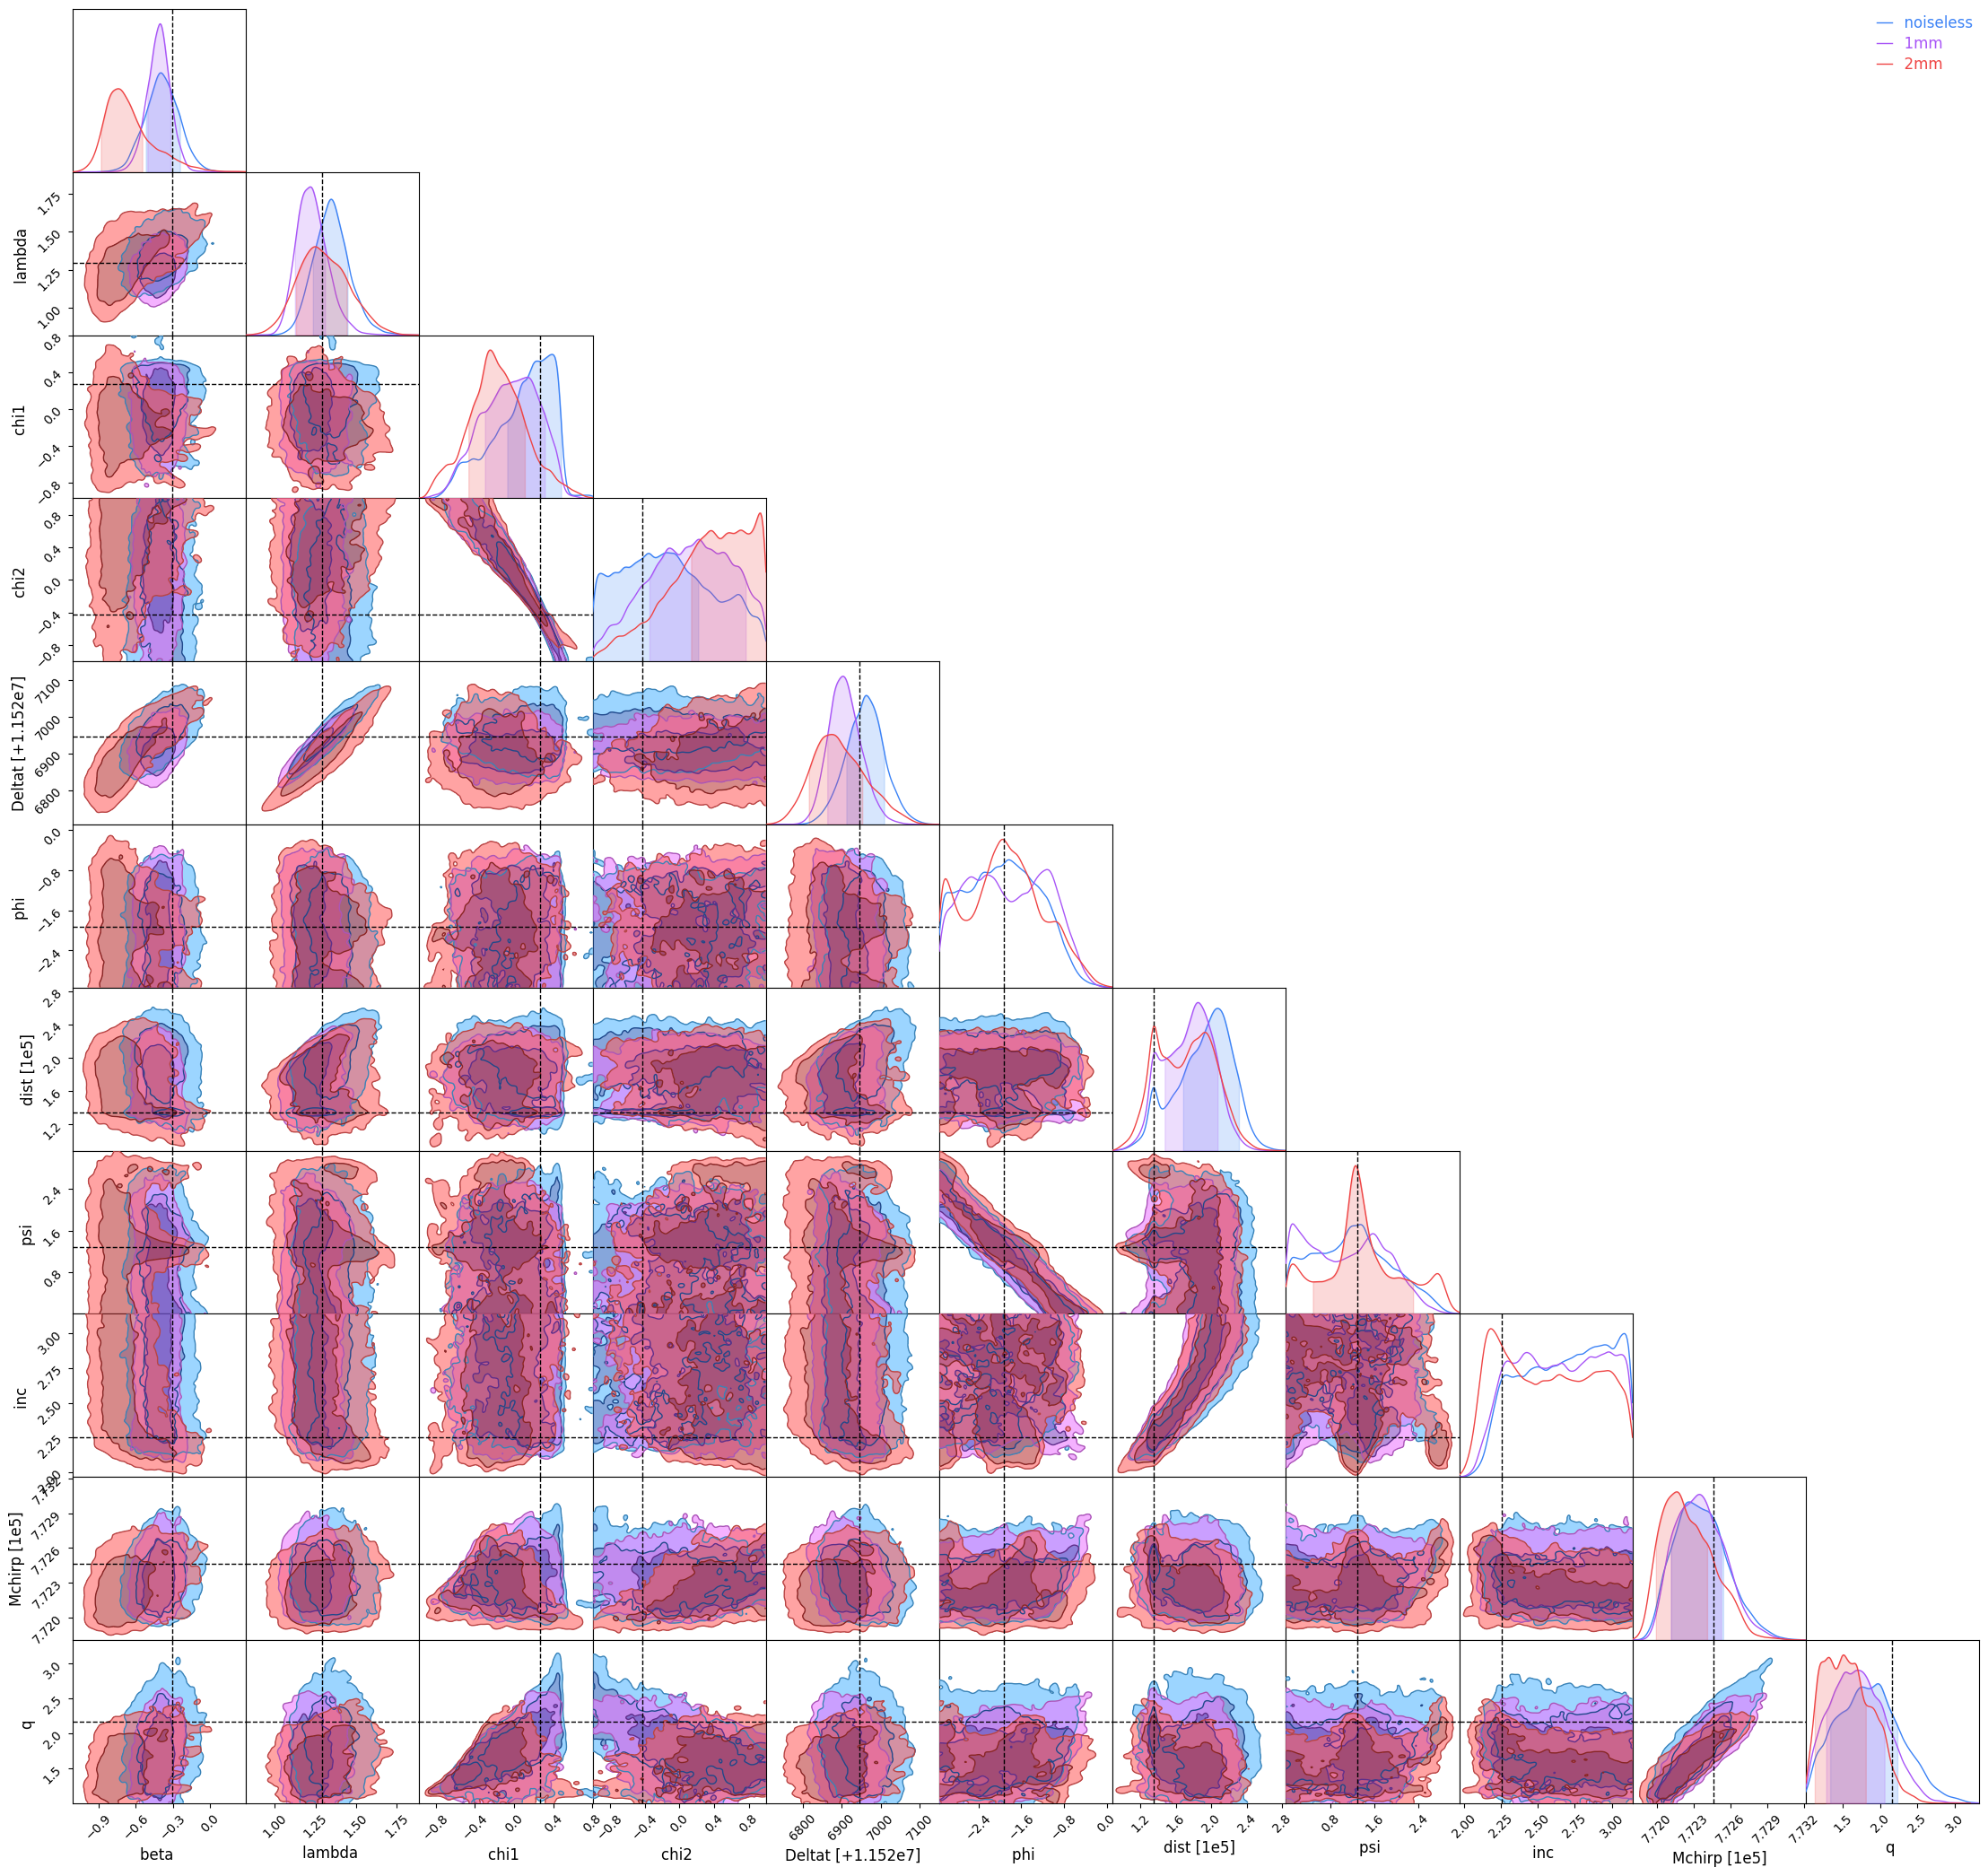

In [127]:
check = ChainConsumer()

check.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
check.add_chain(Chain(samples=one_samp, name="1mm", color="purple"))
check.add_chain(Chain(samples=two_samp, name="2mm", color="red"))
check.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

check.plotter.plot()
#check.plotter.plot_walks()

# Add 10mm noise to data

In [128]:
#generate noise psd for 1mm
psd_sqrt = 8e-10*(np.sin(2*freq/fstar)**2 + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10

noise_fft = randc(psd_sqrt)

#add noisy noise to signal
Afull = A_full+ noise_fft/np.sqrt(df*4)
Efull = E_full+ noise_fft/np.sqrt(df*4)

# Run same MCMC with 10mm noise

In [129]:
sampler4 = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps),
    nleaves_max=dict(mbh=1),
)

In [130]:
sampler4.run_mcmc(start_state, nsamples, progress=True)

100%|██████████| 50000/50000 [22:22<00:00, 37.25it/s]


# Corners and Chains

Parameter phi in chain 10mm is not constrained
Parameter psi in chain 10mm is not constrained


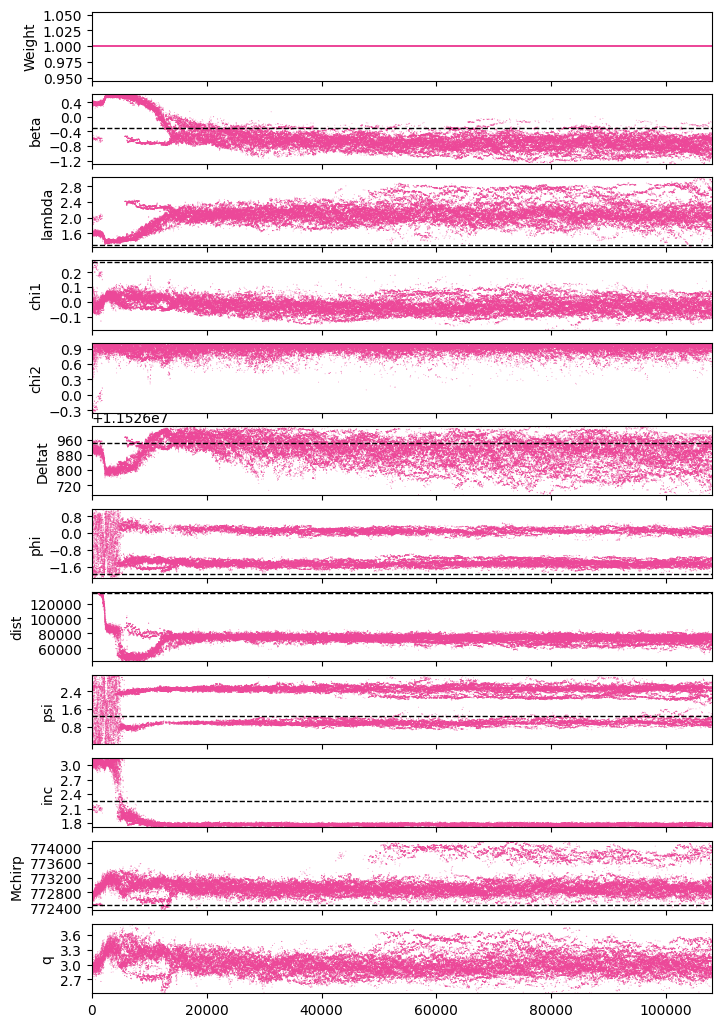

In [131]:
d = ChainConsumer()
ten_samples = sampler4.get_chain()["mbh"][:, 0].reshape(-1, 11)

#burn = 200000
ten_samp= pd.DataFrame(ten_samples[burn:, :], columns = keys)

d.add_chain(Chain(samples=ten_samp, name="10mm", color="pink"))
d.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

d.plotter.plot()
d.plotter.plot_walks()

In [132]:
csv_filename_10mm = "10mm_"+ str(snr) + "_snr_chains.csv"
ten_samp.to_csv(csv_filename_10mm, index=False)
print(f"Chain data saved to {csv_filename_10mm}")

Chain data saved to 10mm_223_snr_chains.csv


# Corners for noiseless, 1, 2, 10mm
- Blue - 0mm
- Purple - 1mm
- Red - 2mm
- Green - 10mm

Parameter phi in chain noiseless is not constrained
Parameter phi in chain 1 mm/rad is not constrained
Parameter phi in chain 2.3 mm/rad is not constrained
Parameter phi in chain 10 mm/rad is not constrained
Parameter dist in chain 2.3 mm/rad is not constrained
Parameter psi in chain noiseless is not constrained
Parameter psi in chain 1 mm/rad is not constrained
Parameter psi in chain 10 mm/rad is not constrained
Parameter inc in chain noiseless is not constrained
Parameter inc in chain 1 mm/rad is not constrained
Parameter inc in chain 2.3 mm/rad is not constrained


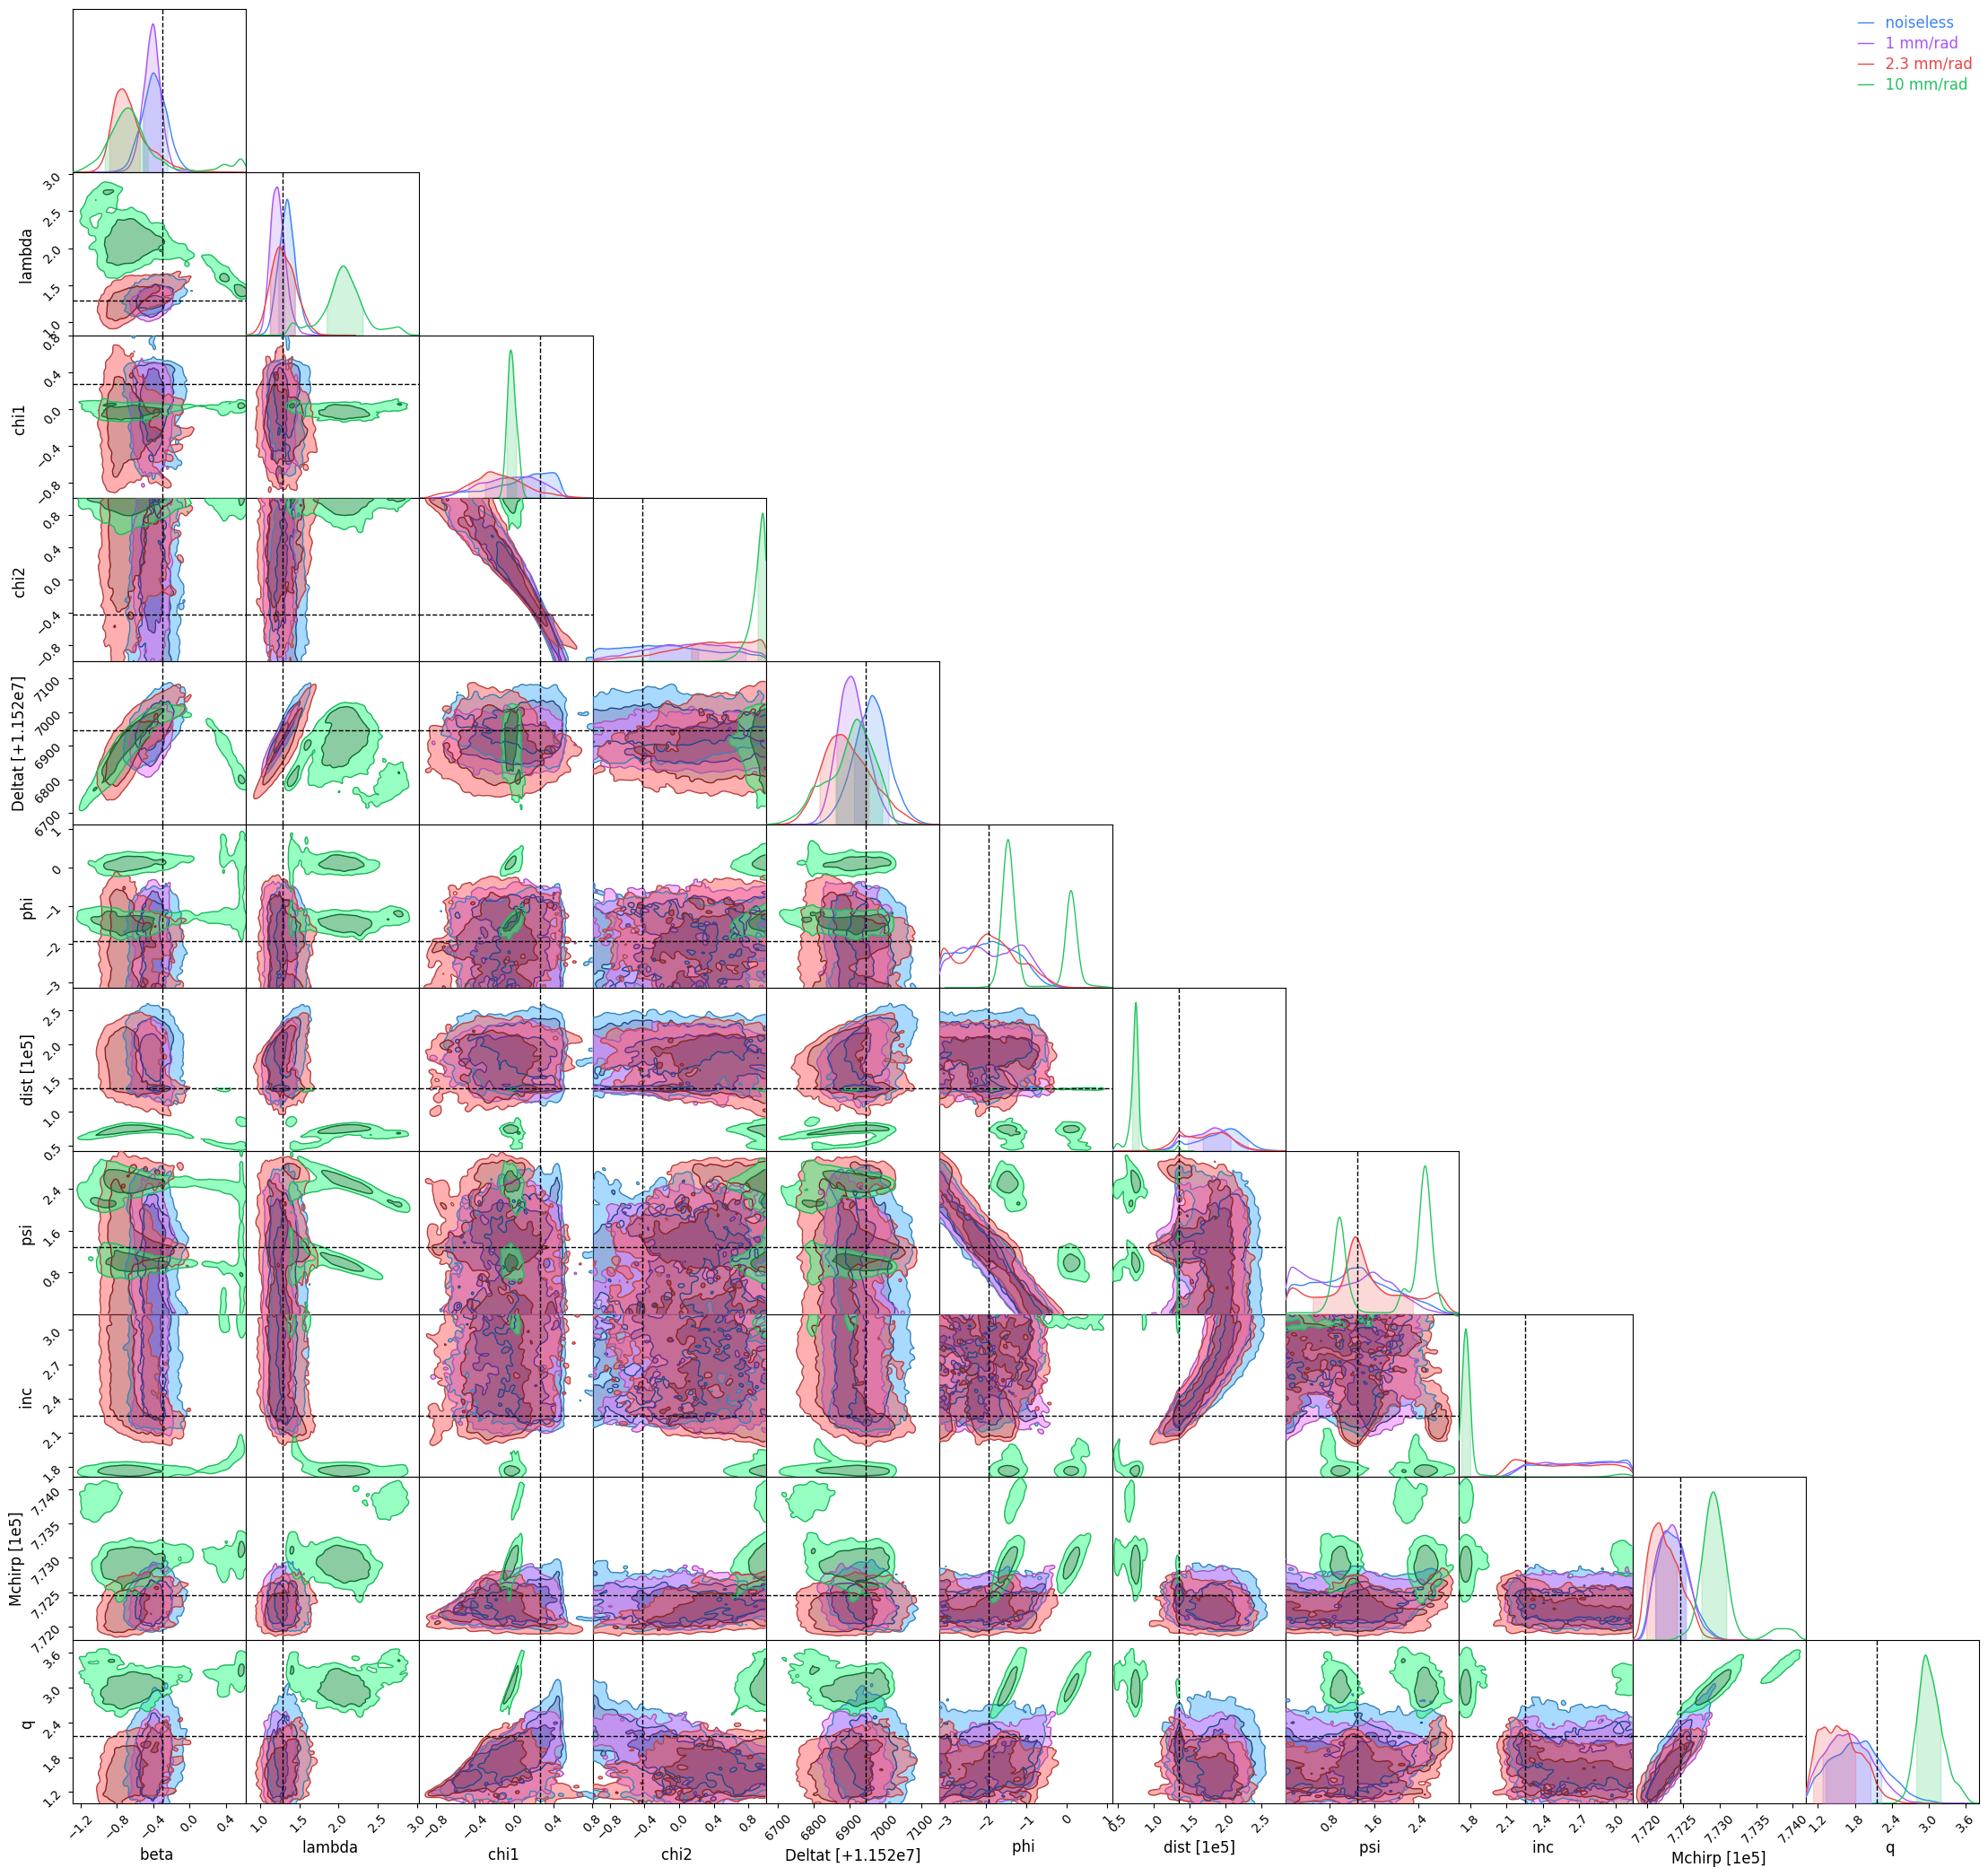

In [133]:
check2 = ChainConsumer()

check2.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
check2.add_chain(Chain(samples=one_samp, name="1 mm/rad", color="purple"))
check2.add_chain(Chain(samples=two_samp, name="2.3 mm/rad", color="red"))
check2.add_chain(Chain(samples=ten_samp, name="10 mm/rad", color="green"))

check2.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))
check2.plotter.plot()

In [134]:
print(truths)

[-3.03004423e-01  1.29251839e+00  2.68631909e-01 -4.21510979e-01
  1.15269449e+07 -1.92139577e+00  1.34700984e+05  1.29122260e+00
  2.25178952e+00  7.72462857e+05  2.16050415e+00]


In [135]:
print(labels_final)

['beta', 'lambda', 'chi1', 'chi2', 'Deltat', 'phi', 'dist', 'psi', 'inc', 'Mchirp', 'q']
